##### 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("data/sha_claims.csv", parse_dates=["claim_date"])

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(25000, 29)
claim_id                             str
member_id                            str
claim_date                datetime64[us]
claim_status                         str
provider_id                          str
provider_name                        str
provider_type                        str
provider_county                      str
member_age                         int64
member_gender                        str
member_county                        str
member_risk_tier                     str
benefit_package                      str
claim_type                           str
diagnosis_code                       str
diagnosis_description                str
procedure_code                       str
procedure_description                str
drug_code                            str
drug_description                     str
admission_days                     int64
consultation_fee_kes             float64
procedure_cost_kes               float64
drug_cost_kes                    float64
lab_

##### 2. Univariate - Financial Distributions

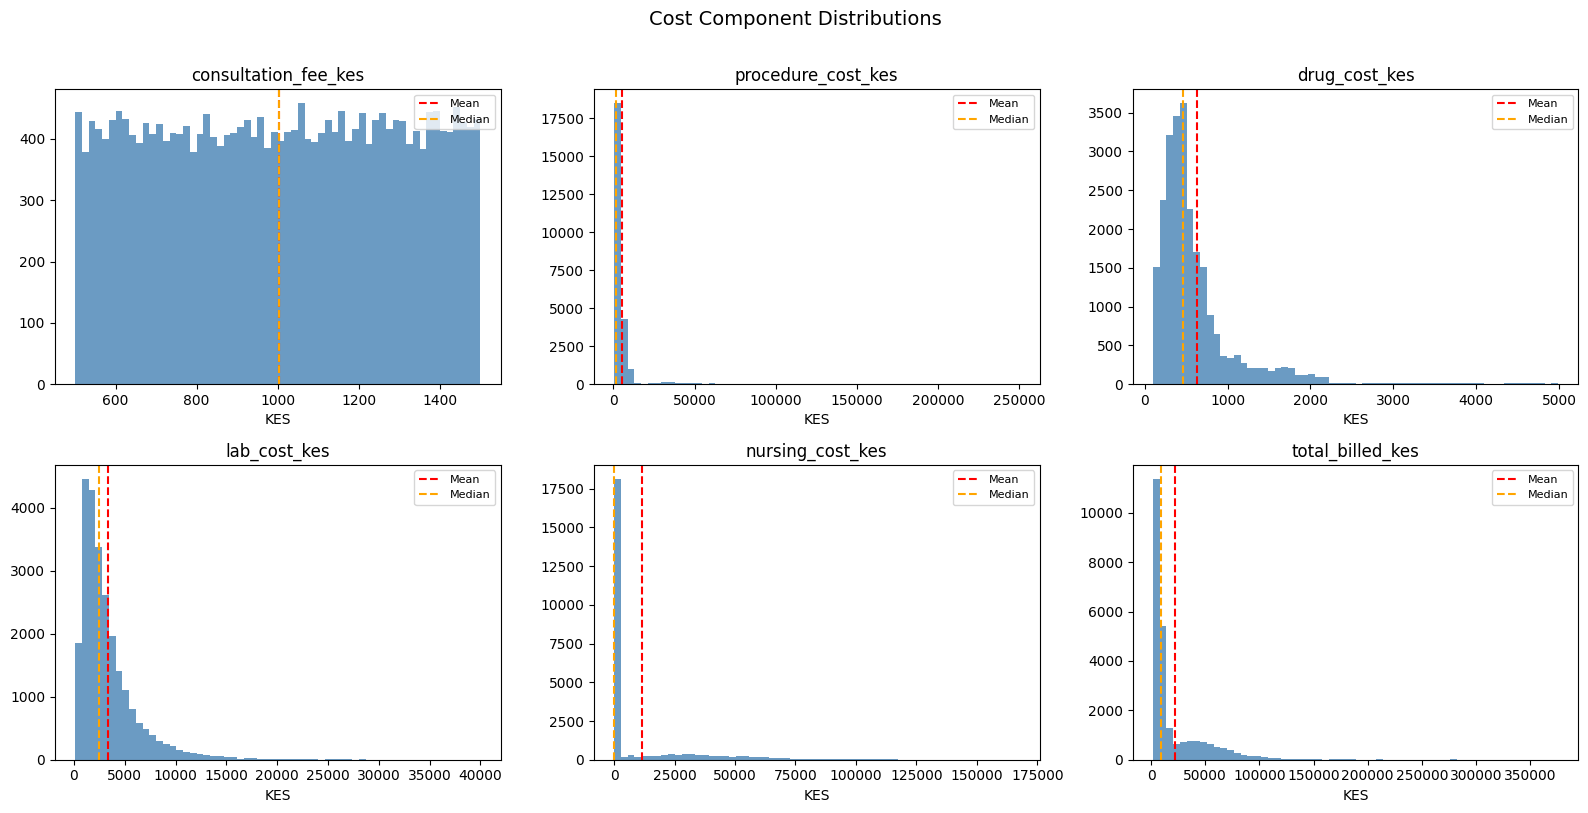

                         count      mean       std      min      25%      50%  \
consultation_fee_kes 25,000.00  1,002.31    289.82   500.00   750.38 1,004.32   
procedure_cost_kes   25,000.00  5,556.52 16,425.65   400.67 1,026.51 1,796.99   
drug_cost_kes        25,000.00    631.59    568.66   100.01   324.19   468.33   
lab_cost_kes         25,000.00  3,368.45  3,115.47   109.87 1,430.93 2,453.53   
nursing_cost_kes     25,000.00 11,402.71 23,372.63     0.00     0.00     0.00   
total_billed_kes     25,000.00 21,961.58 31,358.27 1,723.85 5,321.91 8,820.98   

                           75%        max  skew  
consultation_fee_kes  1,254.22   1,499.91 -0.01  
procedure_cost_kes    4,823.99 249,954.49  9.00  
drug_cost_kes           698.81   4,990.39  3.33  
lab_cost_kes          4,192.60  40,000.00  3.09  
nursing_cost_kes     10,698.23 167,497.51  2.45  
total_billed_kes     26,971.50 375,895.56  3.82  


In [3]:
cost_cols = ["consultation_fee_kes", "procedure_cost_kes",
             "drug_cost_kes", "lab_cost_kes",
             "nursing_cost_kes", "total_billed_kes"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cost_cols):
    axes[i].hist(df[col], bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("KES")
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--", label="Mean")
    axes[i].axvline(df[col].median(), color="orange", linestyle="--", label="Median")
    axes[i].legend(fontsize=8)

plt.suptitle("Cost Component Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary stats + skewness
print(df[cost_cols].describe().T.assign(skew=df[cost_cols].skew()))

##### Interpretations

_consultation_fee_kes_
###### The distribution is almost perfectly flat across KES 500–1,500, with the mean very close to the median and a skew of -0.01. This column appears clean, meaning it has low FWA risk. Under SHA, outpatient consultations are paid against prescribed maximum tariffs, which constrains but does not fully eliminate room for inflation or balance‑billing outside the scheme.

_procedure_cost_kes_
###### A skew of 9.00 is the most extreme. The median is KES 1,797, while the mean is KES 5,557, pulled upward by a long right tail extending to KES 249,954. The bulk of claims cluster below KES 10,000, but the histogram shows a thick right tail. This should be a primary FWA signal column, since procedure cost is often the easiest component to inflate (via upcoding, phantom procedures, or unbundling). The gap between the median and maximum is over 100×, which warrants close provider‑level scrutiny.

_drug_cost_kes_
###### Right‑skewed at 3.33, with a median of KES 468 and a mean of KES 632. The bulk of claims sit below KES 1,000, which is consistent with generic drug dispensing under SHA. The tail up to KES 4,990 likely reflects higher‑cost drugs such as insulin; these should be checked for clinical consistency against the diagnosis codes on the same row (for example, insulin billed against a malaria diagnosis would be a red flag).

_lab_cost_kes_
###### Skew of 3.09, median KES 2,454 versus mean KES 3,368, with a hard cap visible at KES 40,000. The right tail is notable but less extreme than for procedure costs. Lab costs are commonly abused through phantom tests, such as billing for a comprehensive metabolic panel on a routine URTI visit; cross‑referencing with diagnosis_code helps validate clinical necessity.

_nursing_cost_kes_
###### The median and 25th percentile are both KES 0.00, which is expected because outpatient claims should typically have zero nursing cost. The mean of KES 11,403 is driven entirely by inpatient rows. The histogram’s massive spike at zero followed by a spread up to KES 167,498 reflects this two‑population structure. The integrity check here is critical: any row where nursing_cost_kes > 0 and admission_days == 0 is a strong billing‑fraud signal, since nursing care is being charged without an admitted patient.

_total_billed_kes_
###### Skew of 3.82, with a median of KES 8,821 versus a mean of KES 21,962, so the mean is about 2.5 times the median. This is the most important high level signal because it indicates that a relatively small number of high value claims are pulling the average up sharply. The tail extending to KES 375,896 on what should mostly be routine SHA claims is significant. In practice, SHA would expect most claims to sit within a diagnosis specific cost band, so any claim exceeding roughly 3 times the band median for its diagnosis should be queued for automatic review.

###### Takeaway
###### Procedure cost is driving the bulk of total bill inflation. Procedure_cost_kes should be the primary stratification variable in provider profiling, rather than total_billed_kes. A provider can keep total bills moderate while systematically overbilling on procedures; that pattern is hidden in the aggregate but becomes visible when this component is isolated.

##### 3. Outlier Detection — IQR & Z-Score

In [13]:
# IQR-based function for Extreme Outlier Detection
def get_extreme_bounds(series):
    """
    Uses 3.0 (instead of 1.5) * IQR to identify extreme outliers (Outer Fences).
    This is standard for fraud/anomaly detection to minimize false positives.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Lower bound is clipped at 0 since medical costs cannot be negative
    lower_bound = max(0, Q1 - 3 * IQR)
    upper_bound = Q3 + 3 * IQR
    
    return lower_bound, upper_bound

# 1. IQR-based Extreme Outlier Check
print("--- Extreme Outlier Analysis ---")
for col in ["total_billed_kes", "procedure_cost_kes"]:
    lo, hi = get_extreme_bounds(df[col])
    # Rows exceeding the extreme upper fence
    is_outlier = (df[col] < lo) | (df[col] > hi)
    n_out = is_outlier.sum()
    
    print(f"{col:20}: Extreme Upper Bound = KES {hi:,.0f} | Outliers = {n_out} ({n_out/len(df)*100:.1f}%)")

# Z-score flags (Standard Deviation method)
# Z-score is more sensitive to the 'average', while IQR is more robust for skewed data.
df["zscore_total_billed"] = stats.zscore(df["total_billed_kes"])
high_bill_claims = df[df["zscore_total_billed"] > 3]

print(f"\n--- Statistical Outliers (Z-score > 3) ---")
print(f"Total claims flagged: {len(high_bill_claims)}")

# Displaying the top 10 potential anomalies for audit
report_cols = ["claim_id", "provider_name", "diagnosis_description", "total_billed_kes", "claim_type"]
if not high_bill_claims.empty:
    print(high_bill_claims[report_cols].sort_values(by="total_billed_kes", ascending=False).head(10))

--- Extreme Outlier Analysis ---
total_billed_kes    : Extreme Upper Bound = KES 91,920 | Outliers = 800 (3.2%)
procedure_cost_kes  : Extreme Upper Bound = KES 16,216 | Outliers = 1187 (4.7%)

--- Statistical Outliers (Z-score > 3) ---
Total claims flagged: 390
              claim_id             provider_name  \
14288  CLM-2024-712918    Nairobi Women Hospital   
3980   CLM-2023-580850     Narok County Referral   
20068  CLM-2024-747868    Nairobi Women Hospital   
7717   CLM-2023-521842     Narok County Referral   
8531   CLM-2023-687524  Avenue Healthcare Kisumu   
10967  CLM-2023-882185    Coast General Hospital   
22174  CLM-2024-848538   Nakuru Level 5 Hospital   
20444  CLM-2024-267563     Narok County Referral   
3352   CLM-2023-957123   Garissa County Referral   
544    CLM-2023-315313  Premier Hospital Mombasa   

                     diagnosis_description  total_billed_kes claim_type  
14288  Malignant Neoplasm of Bronchus/Lung        375,895.56  Inpatient  
3980   Malignant 

##### 4. Categorical Frequencies

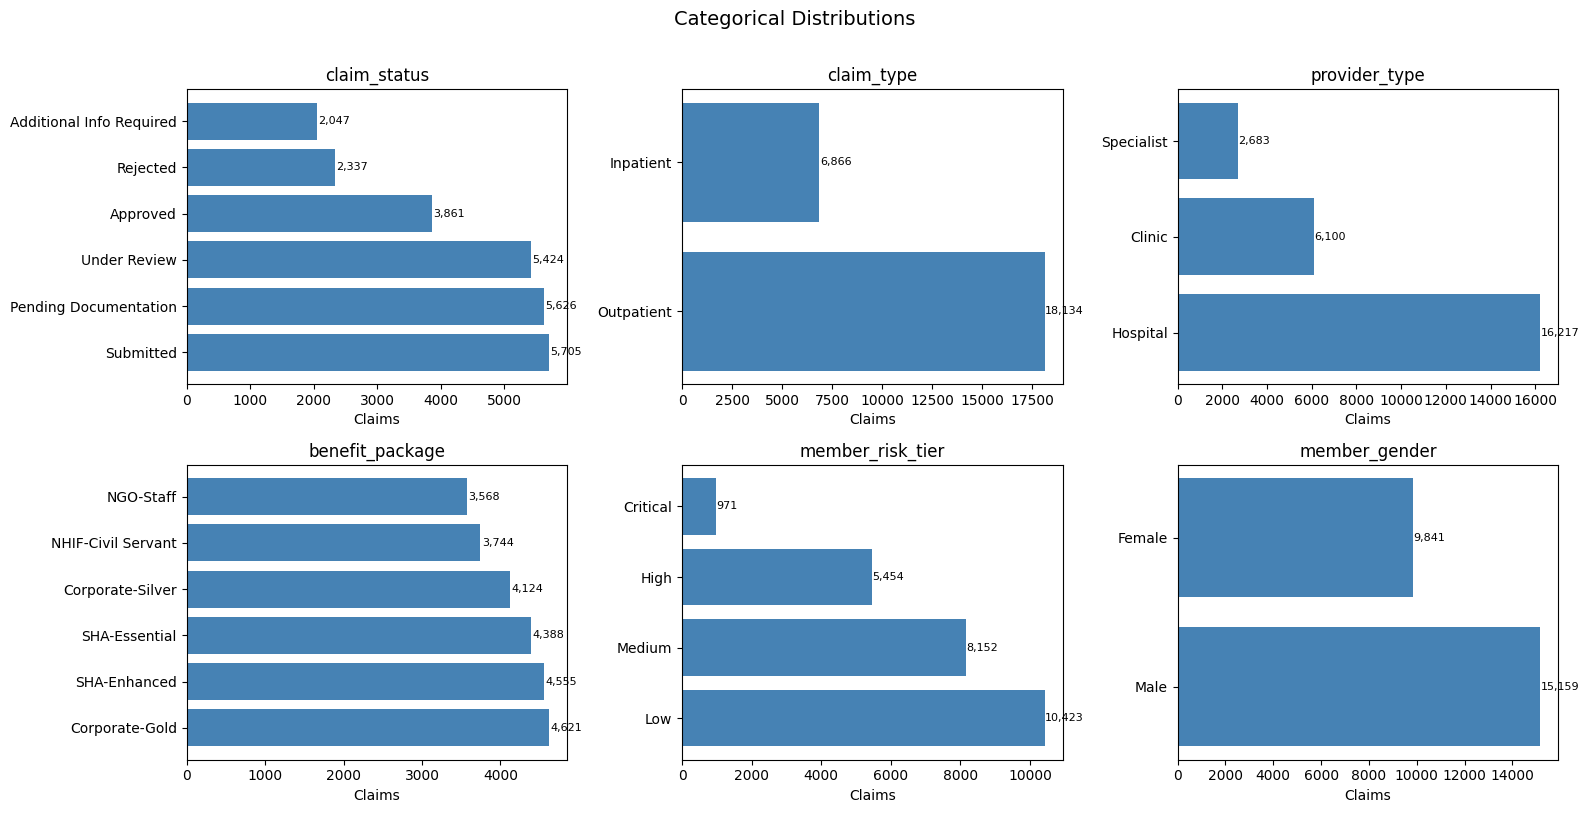

In [17]:
cat_cols = ["claim_status", "claim_type", "provider_type",
            "benefit_package", "member_risk_tier", "member_gender"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color="steelblue", edgecolor="none")
    axes[i].set_title(col)
    axes[i].set_xlabel("Claims")
    for j, v in enumerate(counts.values):
        axes[i].text(v + 20, j, f"{v:,}", va="center", fontsize=8)

plt.suptitle("Categorical Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Interpretations:

_claim_status_
###### The three unresolved statuses (Submitted, Pending Documentation, Under Review) account for the majority of all claims. Only 3,861 claims (15.4%) are Approved, which is operationally alarming given SHA’s current backlog and review challenges. This is the single most operationally concerning finding in this chart, because in a healthy SHA claims pipeline the majority of claims should be resolved (Approved or Rejected) rather than sitting in unresolved statuses.
_claim_type_
###### The outpatient to inpatient ratio is broadly consistent with what SHA-type schemes see in Kenya’s utilisation patterns. However, this aggregate ratio becomes important as a benchmark once it is broken down by provider. Any provider whose inpatient ratio is significantly higher than this benchmark warrants investigation, because inpatient claims carry nursing costs, longer admission days, and higher procedure complexity, all of which are easier to inflate. A clinic (not a hospital) showing a 50%+ inpatient rate would be an immediate red flag given its facility classification.
_provider_type_
###### The provider type distribution is structurally expected. The FWA concern here is not the distribution itself but the cost per claim by provider type. Clinics billing at hospital-level rates are a classic upcoding pattern. When running the provider profiling step, compute average total_billed_kes separately for each provider type and flag any clinic whose average bill exceeds the hospital average, as this inversion is clinically implausible and should be investigated.

_benefit_package_
###### The distribution is relatively balanced across all six packages, ranging from NGO-Staff to Corporate. Corporate-Gold topping the list is the most important signal here. Corporate-Gold members typically have higher benefit limits and less cost-sharing, making them the most attractive targets for over-servicing and upcoding because providers know these members have headroom before benefit caps kick in. It is recommended to specifically check whether Corporate-Gold claims also carry the highest average procedure_cost_kes and whether certain providers disproportionately serve Corporate-Gold members compared to their county population mix. SHA-Essential being the third highest is also notable. These are the lowest-income beneficiaries with the least capacity to verify or dispute what was billed on their behalf, making them vulnerable to identity fraud and phantom claims.


_member_risk_tier_
###### Low risk accounts for most claims, with Medium and High following and Critical at the bottom. Low-risk members should typically utilise health services the least, so if low-risk members are generating the most claims volume, the priority is to check whether the risk stratification model is accurate or whether genuinely sick members are being miscategorised as low-risk. It is also important to check whether low-risk members are being targeted for phantom claims precisely because their profiles do not raise algorithmic alerts, which would indicate deliberate exploitation of the risk model’s blind spots.

_member_gender_
###### The ratio gap in claims made between men and women is large, with men accounting for more claims. In most health utilisation studies, women tend to access healthcare more frequently than men, particularly in reproductive age groups. This male skew is worth investigating from two angles: enrolment bias (if the scheme predominantly covers formal sector workers and dependants, a male-skewed workforce composition could explain it), and phantom member fraud (male identities may be more frequently used in ghost member schemes because they generate fewer biologically triggered verification questions, such as maternity or contraceptive management). Cross-tabulate gender against diagnosis_code — if female-specific diagnosis codes (for example, O80 Normal Delivery, Z30 Contraceptive Management, O82 Caesarean Section) appear against male member IDs, these are definitive data integrity failures and likely fraud.